# Modeling

**Project:** Income Prediction: What Determines Who Earns More? (2.4)

**Team:** Anastasia Sidorova and Paola Cancino

**Date:** 4/19/2026

## What We Will Cover


1. Load preprocessed data
2. Baseline model (Simple Train/Test)
3. Cross-validation
4. Hyperparameter tuning (GridSearchCV)
5. Final model comparision
6. Save the best model

## 1) Load Data

In [3]:
## import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

## settings
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

In [4]:
# load data from feature engineering notebook
X_train = pd.read_csv('/Users/paolacancino/Documents/GitHub/MTSU Team5-C4_IncomePredictions/data/modeling/X_train_scaled.csv')
X_test = pd.read_csv('/Users/paolacancino/Documents/GitHub/MTSU Team5-C4_IncomePredictions/data/modeling/X_test_scaled.csv')
y_train = pd.read_csv('/Users/paolacancino/Documents/GitHub/MTSU Team5-C4_IncomePredictions/data/modeling/y_train.csv').squeeze()
y_test = pd.read_csv('/Users/paolacancino/Documents/GitHub/MTSU Team5-C4_IncomePredictions/data/modeling/y_test.csv').squeeze()

## save WITH SMOTE
X_train_sm = pd.read_csv('/Users/paolacancino/Documents/GitHub/MTSU Team5-C4_IncomePredictions/data/modeling/X_train_smote.csv')
y_train_sm = pd.read_csv('/Users/paolacancino/Documents/GitHub/MTSU Team5-C4_IncomePredictions/data/modeling/y_train_smote.csv').squeeze()

print(f'Training (original): {X_train.shape}')
print(f'Training (SMOTE):    {X_train_sm.shape}')
print(f'Test:                {X_test.shape}')
print(f'\nClass distribution (train): {y_train.value_counts().to_dict()}')
print(f'Class distribution (test):  {y_test.value_counts().to_dict()}')

Training (original): (38080, 93)
Training (SMOTE):    (63618, 93)
Test:                (9512, 93)

Class distribution (train): {0: 31809, 1: 6271}
Class distribution (test):  {0: 7944, 1: 1568}


#### Summary

- **Shapes of datasets:**
  - Training (original): (38,080, 93)
  - Training (SMOTE): (63,618, 93)
  - Test: (9,512, 93)

- **Target distribution (classification):**
  - Training set: {0: 31,809, 1: 6,271}
  - Test set: {0: 7,944, 1: 1,568}

- **Dataset usage for models:**
  - For the logistic regression and SVM, we will use the SMOTE training dataset.
  - For tree-based models, we will use the original unscaled dataset.

## 2) Basic Models

### model 1: logistic regression

In [10]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=4950)
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",4950
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [11]:
y_pred = lr.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [12]:
y_pred[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0])

In [16]:
y_prob = lr.predict_proba(X_test)[:, 1]   # probability of class 1 (yes)
y_prob[:20]

array([0.02972445, 0.00297148, 0.00224547, 0.2253246 , 0.00189397,
       0.32807319, 0.11143522, 0.00477926, 0.00226432, 0.24552477,
       0.22143552, 0.05487542, 0.76493085, 0.40138439, 0.03815635,
       0.05500255, 0.07474309, 0.0291896 , 0.38427077, 0.25932184])

In [18]:
## train metrics — to check for overfitting
y_train_pred = lr.predict(X_train)
y_train_prob = lr.predict_proba(X_train)[:, 1]

In [20]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
auc_train = roc_auc_score(y_train, y_train_prob)
auc_test = roc_auc_score(y_test, y_prob)
print(f'ROC-AUC  Train: {auc_train:.4f}  |  Test: {auc_test:.4f}  |  Gap: {auc_train-auc_test:.4f}')

ROC-AUC  Train: 0.8666  |  Test: 0.8644  |  Gap: 0.0022


In [22]:
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.87      0.96      0.92      7944
         Yes       0.61      0.30      0.40      1568

    accuracy                           0.85      9512
   macro avg       0.74      0.63      0.66      9512
weighted avg       0.83      0.85      0.83      9512



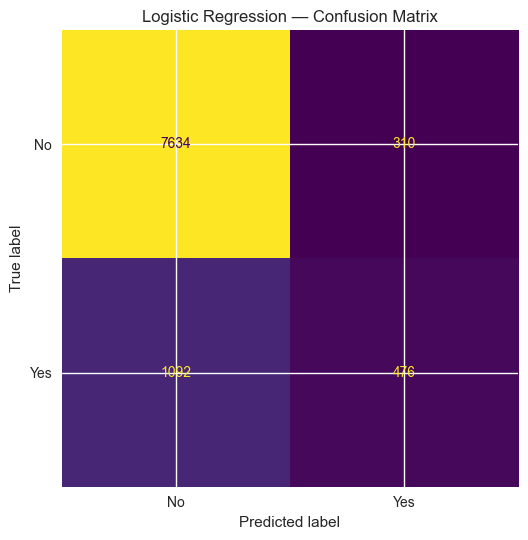

In [24]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['No','Yes'], colorbar=False)
plt.title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

In [26]:
results = []

report = classification_report(y_test, y_pred, target_names=['No','Yes'], output_dict=True)
results.append({
    'Model'          : 'Logistic Regression',
    'Accuracy'       : report['accuracy'],
    'Precision (Yes)': report['Yes']['precision'],
    'Recall (Yes)'   : report['Yes']['recall'],
    'F1 (Yes)'       : report['Yes']['f1-score'],
    'ROC-AUC'        : auc_test,
    'ROC-AUC Train'  : auc_train,
})

results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.8526072329688814,
  'Precision (Yes)': 0.6055979643765903,
  'Recall (Yes)': 0.30357142857142855,
  'F1 (Yes)': 0.40441801189464743,
  'ROC-AUC': 0.8643730363180016,
  'ROC-AUC Train': 0.866585880295049}]

In [28]:
pd.DataFrame(results).round(4)

,Model,Accuracy,Precision (Yes),Recall (Yes),F1 (Yes),ROC-AUC,ROC-AUC Train
0,Logistic Regression,0.8526,0.6056,0.3036,0.4044,0.8644,0.8666


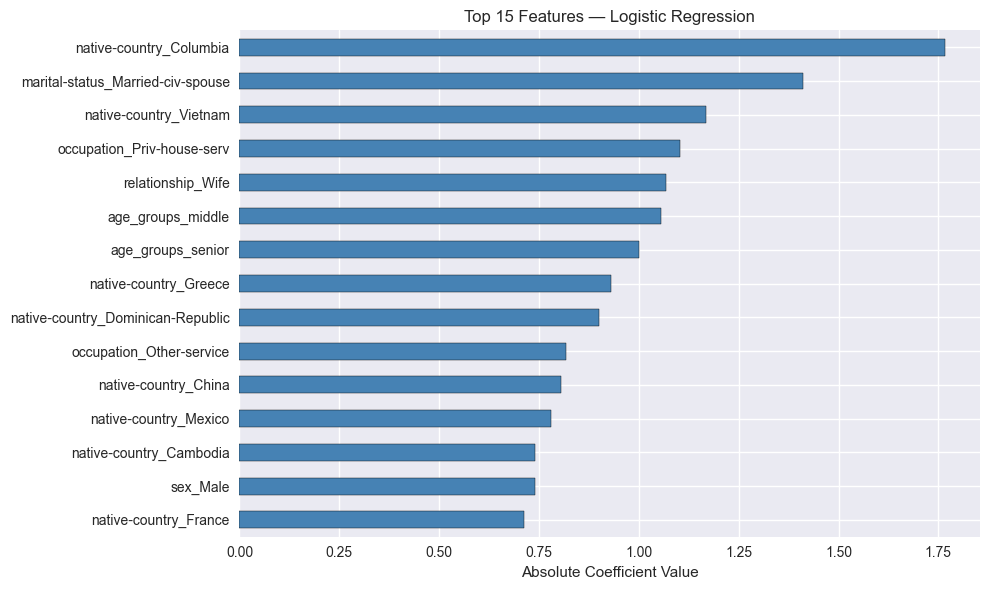

In [30]:
importances = pd.Series(np.abs(lr.coef_[0]), index=X_train.columns)
top15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top15.plot(kind='barh', color='steelblue', edgecolor='black')
plt.xlabel('Absolute Coefficient Value')
plt.title('Top 15 Features — Logistic Regression')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### model 2: SVM

In [33]:
from sklearn.svm import SVC

svm = SVC(probability=True, random_state=4950)
svm.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [34]:
y_pred = svm.predict(X_test)
y_prob = svm.predict_proba(X_test)[:, 1]

y_train_pred = svm.predict(X_train)
y_train_prob = svm.predict_proba(X_train)[:, 1]

auc_train = roc_auc_score(y_train, y_train_prob)
auc_test = roc_auc_score(y_test, y_prob)
print(f'ROC-AUC  Train: {auc_train:.4f}  |  Test: {auc_test:.4f}  |  Gap: {auc_train-auc_test:.4f}')

ROC-AUC  Train: 0.8627  |  Test: 0.8215  |  Gap: 0.0412


In [37]:
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.87      0.97      0.92      7944
         Yes       0.65      0.26      0.37      1568

    accuracy                           0.86      9512
   macro avg       0.76      0.61      0.64      9512
weighted avg       0.83      0.86      0.83      9512



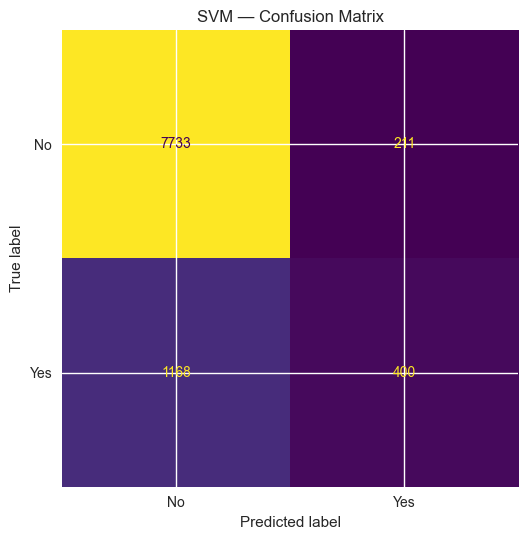

In [39]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                        display_labels=['No', 'Yes'],
                                        colorbar=False)
plt.title('SVM — Confusion Matrix')
plt.tight_layout()
plt.show()

In [41]:
report = classification_report(y_test, y_pred, target_names=['No','Yes'], output_dict=True)
results.append({
    'Model'          : 'SVM',
    'Accuracy'       : report['accuracy'],
    'Precision (Yes)': report['Yes']['precision'],
    'Recall (Yes)'   : report['Yes']['recall'],
    'F1 (Yes)'       : report['Yes']['f1-score'],
    'ROC-AUC'        : auc_test,
    'ROC-AUC Train'  : auc_train,
})

results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.8526072329688814,
  'Precision (Yes)': 0.6055979643765903,
  'Recall (Yes)': 0.30357142857142855,
  'F1 (Yes)': 0.40441801189464743,
  'ROC-AUC': 0.8643730363180016,
  'ROC-AUC Train': 0.866585880295049},
 {'Model': 'SVM',
  'Accuracy': 0.8550252312867956,
  'Precision (Yes)': 0.6546644844517185,
  'Recall (Yes)': 0.25510204081632654,
  'F1 (Yes)': 0.36714089031665903,
  'ROC-AUC': 0.8214653804308731,
  'ROC-AUC Train': 0.8626778618766908}]

In [43]:
pd.DataFrame(results).round(4)

,Model,Accuracy,Precision (Yes),Recall (Yes),F1 (Yes),ROC-AUC,ROC-AUC Train
0,Logistic Regression,0.8526,0.6056,0.3036,0.4044,0.8644,0.8666
1,SVM,0.8550,0.6547,0.2551,0.3671,0.8215,0.8627


### model 3: decision tree

In [46]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier( random_state=4950)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",4950
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [48]:
y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)[:, 1]

y_train_pred = dt.predict(X_train)
y_train_prob = dt.predict_proba(X_train)[:, 1]

auc_train = roc_auc_score(y_train, y_train_prob)
auc_test = roc_auc_score(y_test, y_prob)
print(f'ROC-AUC  Train: {auc_train:.4f}  |  Test: {auc_test:.4f}  |  Gap: {auc_train-auc_test:.4f}')

ROC-AUC  Train: 0.9976  |  Test: 0.6752  |  Gap: 0.3224


In [50]:
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.88      0.89      0.89      7944
         Yes       0.43      0.40      0.42      1568

    accuracy                           0.81      9512
   macro avg       0.66      0.65      0.65      9512
weighted avg       0.81      0.81      0.81      9512



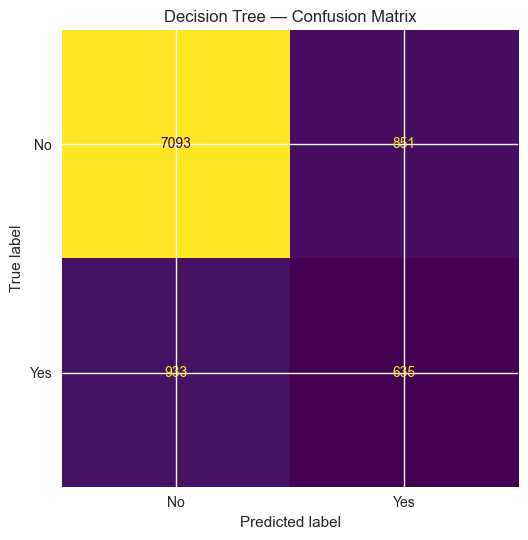

In [52]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['No','Yes'], colorbar=False)
plt.title('Decision Tree — Confusion Matrix')
plt.tight_layout()
plt.show()

In [54]:
report = classification_report(y_test, y_pred, target_names=['No','Yes'], output_dict=True)
results.append({
    'Model'          : 'Decision Tree',
    'Accuracy'       : report['accuracy'],
    'Precision (Yes)': report['Yes']['precision'],
    'Recall (Yes)'   : report['Yes']['recall'],
    'F1 (Yes)'       : report['Yes']['f1-score'],
    'ROC-AUC'        : auc_test,
    'ROC-AUC Train'  : auc_train,
})

results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.8526072329688814,
  'Precision (Yes)': 0.6055979643765903,
  'Recall (Yes)': 0.30357142857142855,
  'F1 (Yes)': 0.40441801189464743,
  'ROC-AUC': 0.8643730363180016,
  'ROC-AUC Train': 0.866585880295049},
 {'Model': 'SVM',
  'Accuracy': 0.8550252312867956,
  'Precision (Yes)': 0.6546644844517185,
  'Recall (Yes)': 0.25510204081632654,
  'F1 (Yes)': 0.36714089031665903,
  'ROC-AUC': 0.8214653804308731,
  'ROC-AUC Train': 0.8626778618766908},
 {'Model': 'Decision Tree',
  'Accuracy': 0.8124474348191758,
  'Precision (Yes)': 0.42732166890982504,
  'Recall (Yes)': 0.4049744897959184,
  'F1 (Yes)': 0.4158480681074001,
  'ROC-AUC': 0.6752429634995993,
  'ROC-AUC Train': 0.9976176923778112}]

In [56]:
pd.DataFrame(results).round(4)

,Model,Accuracy,Precision (Yes),Recall (Yes),F1 (Yes),ROC-AUC,ROC-AUC Train
0,Logistic Regression,0.8526,0.6056,0.3036,0.4044,0.8644,0.8666
1,SVM,0.8550,0.6547,0.2551,0.3671,0.8215,0.8627
2,Decision Tree,0.8124,0.4273,0.4050,0.4158,0.6752,0.9976


### model 4: random forest

In [59]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=4950, n_jobs=-1)  ##An ensemble of 100 independent decision trees.
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [61]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

y_train_pred = rf.predict(X_train)
y_train_prob = rf.predict_proba(X_train)[:, 1]

auc_train = roc_auc_score(y_train, y_train_prob)
auc_test = roc_auc_score(y_test, y_prob)
print(f'ROC-AUC  Train: {auc_train:.4f}  |  Test: {auc_test:.4f}  |  Gap: {auc_train-auc_test:.4f}')

ROC-AUC  Train: 0.9959  |  Test: 0.8446  |  Gap: 0.1513


In [63]:
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.89      0.93      0.91      7944
         Yes       0.54      0.40      0.46      1568

    accuracy                           0.84      9512
   macro avg       0.71      0.67      0.68      9512
weighted avg       0.83      0.84      0.83      9512



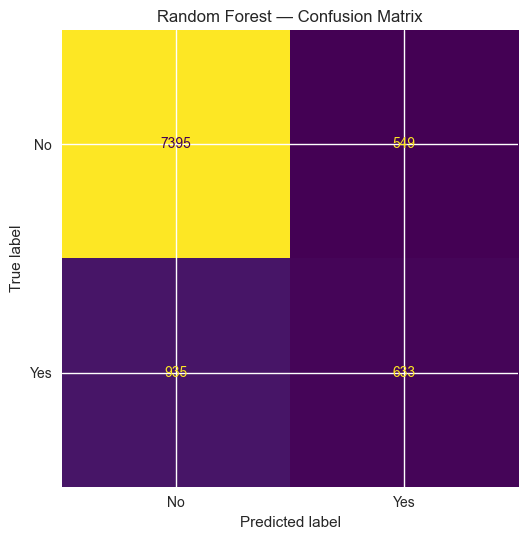

In [65]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['No','Yes'], colorbar=False)
plt.title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

In [67]:
report = classification_report(y_test, y_pred, target_names=['No','Yes'], output_dict=True)
results.append({
    'Model'          : 'Random Forest',
    'Accuracy'       : report['accuracy'],
    'Precision (Yes)': report['Yes']['precision'],
    'Recall (Yes)'   : report['Yes']['recall'],
    'F1 (Yes)'       : report['Yes']['f1-score'],
    'ROC-AUC'        : auc_test,
    'ROC-AUC Train'  : auc_train,
})

results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.8526072329688814,
  'Precision (Yes)': 0.6055979643765903,
  'Recall (Yes)': 0.30357142857142855,
  'F1 (Yes)': 0.40441801189464743,
  'ROC-AUC': 0.8643730363180016,
  'ROC-AUC Train': 0.866585880295049},
 {'Model': 'SVM',
  'Accuracy': 0.8550252312867956,
  'Precision (Yes)': 0.6546644844517185,
  'Recall (Yes)': 0.25510204081632654,
  'F1 (Yes)': 0.36714089031665903,
  'ROC-AUC': 0.8214653804308731,
  'ROC-AUC Train': 0.8626778618766908},
 {'Model': 'Decision Tree',
  'Accuracy': 0.8124474348191758,
  'Precision (Yes)': 0.42732166890982504,
  'Recall (Yes)': 0.4049744897959184,
  'F1 (Yes)': 0.4158480681074001,
  'ROC-AUC': 0.6752429634995993,
  'ROC-AUC Train': 0.9976176923778112},
 {'Model': 'Random Forest',
  'Accuracy': 0.843986543313709,
  'Precision (Yes)': 0.5355329949238579,
  'Recall (Yes)': 0.40369897959183676,
  'F1 (Yes)': 0.46036363636363636,
  'ROC-AUC': 0.8445805507814907,
  'ROC-AUC Train': 0.99589614677011}]

In [69]:
pd.DataFrame(results).round(4)

,Model,Accuracy,Precision (Yes),Recall (Yes),F1 (Yes),ROC-AUC,ROC-AUC Train
0,Logistic Regression,0.8526,0.6056,0.3036,0.4044,0.8644,0.8666
1,SVM,0.8550,0.6547,0.2551,0.3671,0.8215,0.8627
2,Decision Tree,0.8124,0.4273,0.4050,0.4158,0.6752,0.9976
3,Random Forest,0.8440,0.5355,0.4037,0.4604,0.8446,0.9959


### model 5: gradient boosting 

In [72]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=4950)
gb.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [73]:
y_pred = gb.predict(X_test)
y_prob = gb.predict_proba(X_test)[:, 1]

y_train_pred = gb.predict(X_train)
y_train_prob = gb.predict_proba(X_train)[:, 1]

auc_train = roc_auc_score(y_train, y_train_prob)
auc_test = roc_auc_score(y_test, y_prob)
print(f'ROC-AUC  Train: {auc_train:.4f}  |  Test: {auc_test:.4f}  |  Gap: {auc_train-auc_test:.4f}')

ROC-AUC  Train: 0.8855  |  Test: 0.8766  |  Gap: 0.0089


In [74]:
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.89      0.95      0.92      7944
         Yes       0.62      0.40      0.48      1568

    accuracy                           0.86      9512
   macro avg       0.76      0.67      0.70      9512
weighted avg       0.84      0.86      0.85      9512



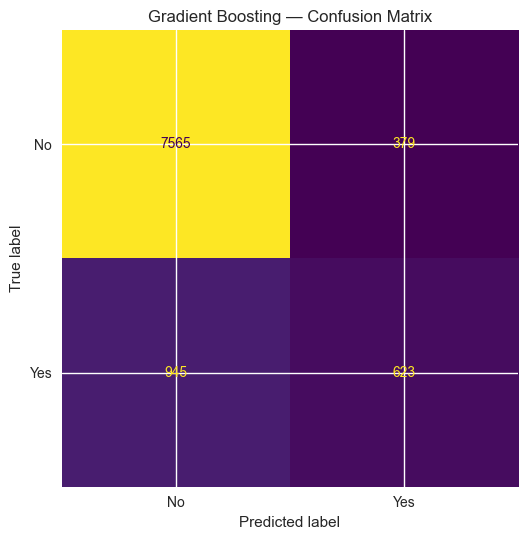

In [75]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['No','Yes'], colorbar=False)
plt.title('Gradient Boosting — Confusion Matrix')
plt.tight_layout()
plt.show()

In [76]:
report = classification_report(y_test, y_pred, target_names=['No','Yes'], output_dict=True)
results.append({
    'Model'          : 'Gradient Boosting',
    'Accuracy'       : report['accuracy'],
    'Precision (Yes)': report['Yes']['precision'],
    'Recall (Yes)'   : report['Yes']['recall'],
    'F1 (Yes)'       : report['Yes']['f1-score'],
    'ROC-AUC'        : auc_test,
    'ROC-AUC Train'  : auc_train,
})

results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.8526072329688814,
  'Precision (Yes)': 0.6055979643765903,
  'Recall (Yes)': 0.30357142857142855,
  'F1 (Yes)': 0.40441801189464743,
  'ROC-AUC': 0.8643730363180016,
  'ROC-AUC Train': 0.866585880295049},
 {'Model': 'SVM',
  'Accuracy': 0.8550252312867956,
  'Precision (Yes)': 0.6546644844517185,
  'Recall (Yes)': 0.25510204081632654,
  'F1 (Yes)': 0.36714089031665903,
  'ROC-AUC': 0.8214653804308731,
  'ROC-AUC Train': 0.8626778618766908},
 {'Model': 'Decision Tree',
  'Accuracy': 0.8124474348191758,
  'Precision (Yes)': 0.42732166890982504,
  'Recall (Yes)': 0.4049744897959184,
  'F1 (Yes)': 0.4158480681074001,
  'ROC-AUC': 0.6752429634995993,
  'ROC-AUC Train': 0.9976176923778112},
 {'Model': 'Random Forest',
  'Accuracy': 0.843986543313709,
  'Precision (Yes)': 0.5355329949238579,
  'Recall (Yes)': 0.40369897959183676,
  'F1 (Yes)': 0.46036363636363636,
  'ROC-AUC': 0.8445805507814907,
  'ROC-AUC Train': 0.99589614677011},
 {'Model'

In [82]:
pd.DataFrame(results).round(4)

,Model,Accuracy,Precision (Yes),Recall (Yes),F1 (Yes),ROC-AUC,ROC-AUC Train
0,Logistic Regression,0.8526,0.6056,0.3036,0.4044,0.8644,0.8666
1,SVM,0.8550,0.6547,0.2551,0.3671,0.8215,0.8627
2,Decision Tree,0.8124,0.4273,0.4050,0.4158,0.6752,0.9976
3,Random Forest,0.8440,0.5355,0.4037,0.4604,0.8446,0.9959
4,Gradient Boosting,0.8608,0.6218,0.3973,0.4848,0.8766,0.8855


In [84]:
results_df = pd.DataFrame(results)

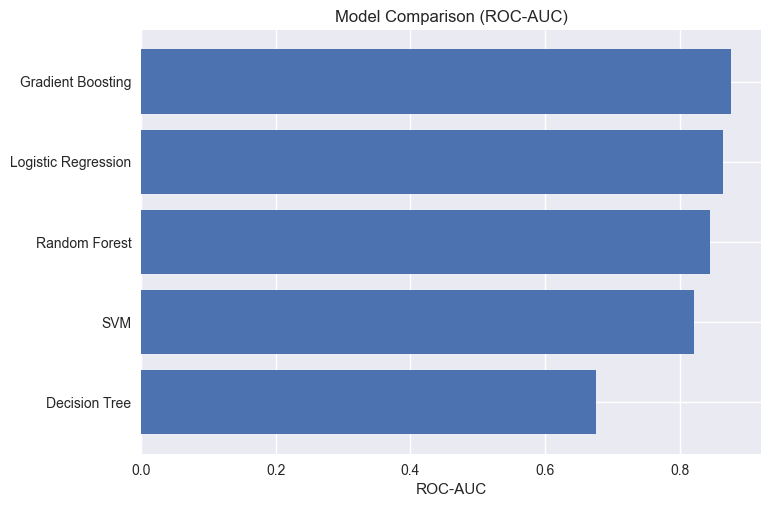

In [86]:
# Sort by primary metric (ROC-AUC)
results_sorted = results_df.sort_values(by="ROC-AUC", ascending=True)

# Horizontal bar chart
plt.figure()
plt.barh(results_sorted["Model"], results_sorted["ROC-AUC"])
plt.xlabel("ROC-AUC")
plt.title("Model Comparison (ROC-AUC)")
plt.show()

#### **Model Comparison Summary**

Based on the ROC-AUC scores, Gradient Boosting performed the best overall with a score of 0.8766. It also has the highest F1 score, which shows it has the best balance between precision and recall for predicting the positive class.

The Decision Tree and Random Forest models show clear overfitting. Their training ROC-AUC scores (0.9976 and 0.9959) are way higher than their test scores, which means they fit the training data too well but don’t perform as well on new data.

Logistic Regression performed more consistently, as its train and test ROC-AUC scores are very similar, but its recall is quite low. The SVM model had the highest precision but the lowest recall, meaning it’s more strict when predicting the positive class.

I would tune:
- Gradient Boosting
- Random Forest
- Logistic Regression

## model comparison: original vs. SMOTE

In [90]:
lr_s = LogisticRegression(max_iter=1000, random_state=4950)
lr_s.fit(X_train_sm, y_train_sm)

dt_s = DecisionTreeClassifier(random_state=4950)
dt_s.fit(X_train_sm, y_train_sm)

rf_s = RandomForestClassifier(n_estimators=100, random_state=4950, n_jobs=-1)
rf_s.fit(X_train_sm, y_train_sm)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [92]:
## collect AUC for both versions

result_smote = {}
for name, orig, smote in [('Logistic Regression', lr, lr_s),
                           ('Decision Tree',       dt, dt_s),
                           ('Random Forest',       rf, rf_s)]:

    auc_orig  = roc_auc_score(y_test, orig.predict_proba(X_test)[:, 1])
    auc_smote = roc_auc_score(y_test, smote.predict_proba(X_test)[:, 1])
    result_smote[name] = {'Original': round(auc_orig, 4),
                     'SMOTE':    round(auc_smote, 4),
                     'Gain':     round(auc_smote - auc_orig, 4)}

smote_comparison = pd.DataFrame(result_smote).T.reset_index()
smote_comparison.columns = ['Model', 'Original AUC', 'SMOTE AUC', 'Gain']

print('SMOTE vs Original — ROC-AUC on Test Set:')
print(smote_comparison)

SMOTE vs Original — ROC-AUC on Test Set:
                 Model  Original AUC  SMOTE AUC    Gain
0  Logistic Regression        0.8644     0.7658 -0.0986
1        Decision Tree        0.6752     0.5024 -0.1729
2        Random Forest        0.8446     0.7725 -0.0721


In [94]:
print('Logistic Regression')
print('=== Without SMOTE ===')
print(classification_report(y_test, lr.predict(X_test), target_names=['No', 'Yes']))

print('=== With SMOTE ===')
print(classification_report(y_test, lr_s.predict(X_test), target_names=['No', 'Yes']))

Logistic Regression
=== Without SMOTE ===
              precision    recall  f1-score   support

          No       0.87      0.96      0.92      7944
         Yes       0.61      0.30      0.40      1568

    accuracy                           0.85      9512
   macro avg       0.74      0.63      0.66      9512
weighted avg       0.83      0.85      0.83      9512

=== With SMOTE ===
              precision    recall  f1-score   support

          No       0.84      1.00      0.91      7944
         Yes       0.33      0.00      0.00      1568

    accuracy                           0.83      9512
   macro avg       0.58      0.50      0.46      9512
weighted avg       0.75      0.83      0.76      9512



In [96]:
print('Decision Tree')
print('=== Without SMOTE ===')
print(classification_report(y_test, dt.predict(X_test), target_names=['No', 'Yes']))

print('=== With SMOTE ===')
print(classification_report(y_test, dt_s.predict(X_test), target_names=['No', 'Yes']))

Decision Tree
=== Without SMOTE ===
              precision    recall  f1-score   support

          No       0.88      0.89      0.89      7944
         Yes       0.43      0.40      0.42      1568

    accuracy                           0.81      9512
   macro avg       0.66      0.65      0.65      9512
weighted avg       0.81      0.81      0.81      9512

=== With SMOTE ===
              precision    recall  f1-score   support

          No       0.84      0.99      0.91      7944
         Yes       0.23      0.01      0.03      1568

    accuracy                           0.83      9512
   macro avg       0.53      0.50      0.47      9512
weighted avg       0.74      0.83      0.76      9512



In [98]:
print('Random Forest')
print('=== Without SMOTE ===')
print(classification_report(y_test, rf.predict(X_test), target_names=['No', 'Yes']))

print('=== With SMOTE ===')
print(classification_report(y_test, rf_s.predict(X_test), target_names=['No', 'Yes']))

Random Forest
=== Without SMOTE ===
              precision    recall  f1-score   support

          No       0.89      0.93      0.91      7944
         Yes       0.54      0.40      0.46      1568

    accuracy                           0.84      9512
   macro avg       0.71      0.67      0.68      9512
weighted avg       0.83      0.84      0.83      9512

=== With SMOTE ===
              precision    recall  f1-score   support

          No       0.84      1.00      0.91      7944
         Yes       0.00      0.00      0.00      1568

    accuracy                           0.84      9512
   macro avg       0.42      0.50      0.46      9512
weighted avg       0.70      0.84      0.76      9512



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


#### **SMOTE vs Original Data Comparison**

SMOTE did not improve model performance. ROC-AUC stayed the same for Logistic Regression and decreased for Decision Tree and Random Forest. Recall also worsened; Logistic Regression remained at 0, while Decision Tree and Random Forest dropped significantly.

Because of this, we will use the original training dataset for the rest of the notebook. It provides better overall performance and better minority class recall compared to the SMOTE data.

## 3) Cross-Validation

In [103]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=4950)

In [105]:
cv_results = []

for name, model in [('Random Forest', rf), ('Gradient Boosting', gb),
                    ('Logistic Regression', lr), ('SVM', svm), ('Decision Tree', dt)]:
    
    scores = cross_val_score(model, X_train, y_train,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
    
    print(f'{name}')
    print(f'  Fold scores: {np.round(scores, 4)}')
    print(f'  Mean: {scores.mean():.4f}  Std: {scores.std():.4f}')
    print()
    
    # Store results
    cv_results.append({
        "Model": name,
        "CV Mean": scores.mean(),
        "CV Std": scores.std(),
        "Fold 1": scores[0],
        "Fold 2": scores[1],
        "Fold 3": scores[2],
        "Fold 4": scores[3],
        "Fold 5": scores[4]
    })

Random Forest
  Fold scores: [0.8574 0.8433 0.8393 0.8465 0.8391]
  Mean: 0.8451  Std: 0.0067

Gradient Boosting
  Fold scores: [0.8855 0.88   0.8762 0.8808 0.874 ]
  Mean: 0.8793  Std: 0.0040

Logistic Regression
  Fold scores: [0.87   0.8633 0.8622 0.867  0.8585]
  Mean: 0.8642  Std: 0.0040

SVM
  Fold scores: [0.8201 0.8252 0.8223 0.8184 0.8201]
  Mean: 0.8212  Std: 0.0024

Decision Tree
  Fold scores: [0.6741 0.6662 0.6748 0.673  0.6653]
  Mean: 0.6707  Std: 0.0041



In [113]:
cv_df = pd.DataFrame(cv_results)
cv_df_sorted = cv_df.sort_values(by="CV Mean", ascending=True)

cv_df_sorted

,Model,CV Mean,CV Std,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
4,Decision Tree,0.670675,0.004077,0.674085,0.666160,0.674804,0.673002,0.665326
3,SVM,0.821215,0.002365,0.820107,0.825235,0.822294,0.818368,0.820073
0,Random Forest,0.845123,0.006739,0.857432,0.843299,0.839324,0.846498,0.839062
2,Logistic Regression,0.864222,0.003983,0.870044,0.863269,0.862226,0.867049,0.858519
1,Gradient Boosting,0.879279,0.003963,0.885465,0.879964,0.876230,0.880775,0.873961


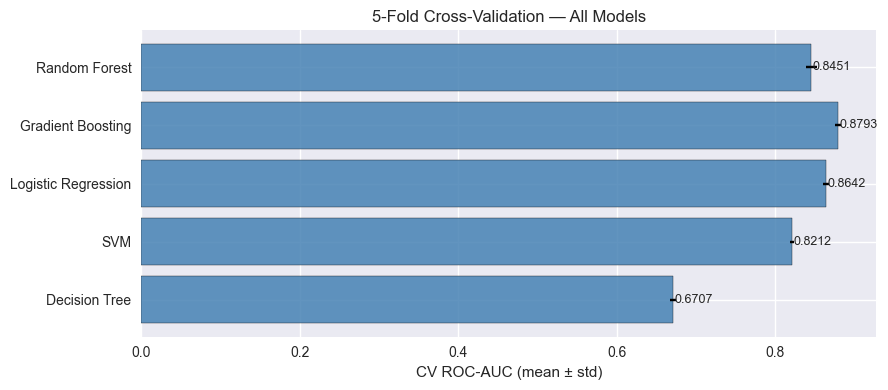

In [115]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(cv_df['Model'], cv_df['CV Mean'], xerr=cv_df['CV Std'],
        color='steelblue', edgecolor='black', capsize=4, alpha=0.85)
ax.set_xlabel('CV ROC-AUC (mean ± std)')
ax.set_title('5-Fold Cross-Validation — All Models')
ax.invert_yaxis()
for i, v in enumerate(cv_df['CV Mean']):
    ax.text(v+0.002, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

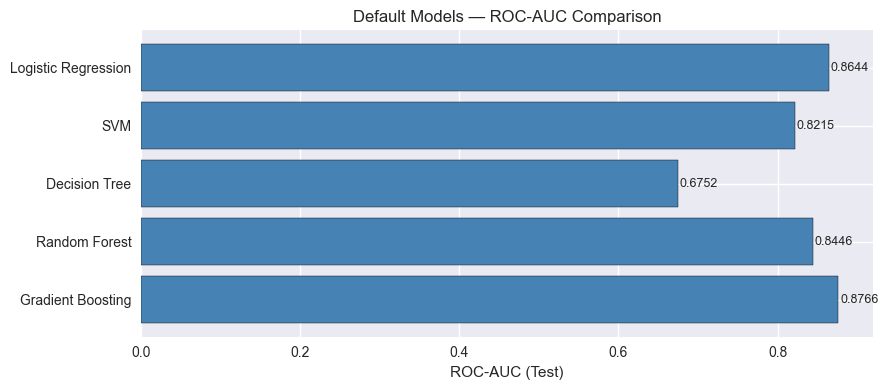

In [117]:
fig, ax = plt.subplots(figsize=(9,4))
ax.barh(results_df['Model'], results_df['ROC-AUC'], color='steelblue', edgecolor='black')
ax.set_xlabel('ROC-AUC (Test)')
ax.set_title('Default Models — ROC-AUC Comparison')
ax.invert_yaxis()
for i, v in enumerate(results_df['ROC-AUC']):
    ax.text(v+0.002, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

### Cross-Validation Summary

Overall, the cross-validation results are very consistent with the test set results from earlier. Gradient Boosting is still the best-performing model with the highest ROC-AUC, followed by Logistic Regression and Random Forest. SVM is slightly lower, and Decision Tree is still the worst-performing model.

The CV mean scores are very close to the test ROC-AUC values, which shows that the models are generalizing well and the test results are reliable. No model has a CV Std greater than 0.03, so there are no major concerns about variability across folds.

## 4) Hyperparameter Tuning

In [121]:
from sklearn.model_selection import GridSearchCV

### tuning: logistic regression

In [163]:
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1','l2'],
    'solver': ['liblinear']
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=4950),
    param_grid=lr_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train, y_train)

print(f'Best params: {lr_grid.best_params_}')
print(f'Best CV AUC: {lr_grid.best_score_:.4f}')

Fitting 5 folds for each of 8 candidates, totalling 40 fits


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0

Best params: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV AUC: 0.8642


In [164]:
lr_cv = (pd.DataFrame(lr_grid.cv_results_)
              [['param_C', 'param_penalty','param_solver',
                'mean_test_score', 'std_test_score', 'rank_test_score']]
              .sort_values('rank_test_score')
              .head(5)
              .round(4)
              .reset_index(drop=True))

print('Top 5 Logistic Regression parameter combinations:')
print(lr_cv)

Top 5 Logistic Regression parameter combinations:
   param_C param_penalty param_solver  mean_test_score  std_test_score  \
0      1.0            l2    liblinear           0.8642          0.0040   
1      1.0            l1    liblinear           0.8642          0.0040   
2      0.1            l2    liblinear           0.8640          0.0045   
3     10.0            l2    liblinear           0.8640          0.0038   
4      0.1            l1    liblinear           0.8639          0.0044   

   rank_test_score  
0                1  
1                2  
2                3  
3                4  
4                5  


In [167]:
y_pred = lr_grid.best_estimator_.predict(X_test)
y_prob = lr_grid.best_estimator_.predict_proba(X_test)[:, 1]
auc_train  = roc_auc_score(y_train, lr_grid.best_estimator_.predict_proba(X_train)[:,1])
auc_test   = roc_auc_score(y_test, y_prob)

print(f'ROC-AUC  Train: {auc_train:.4f}  |  Test: {auc_test:.4f}  |  Gap: {auc_train-auc_test:.4f}')
print(classification_report(y_test, y_pred, target_names=['No','Yes']))

ROC-AUC  Train: 0.8666  |  Test: 0.8646  |  Gap: 0.0020
              precision    recall  f1-score   support

          No       0.88      0.96      0.92      7944
         Yes       0.61      0.31      0.41      1568

    accuracy                           0.85      9512
   macro avg       0.74      0.63      0.66      9512
weighted avg       0.83      0.85      0.83      9512



In [130]:
report = classification_report(y_test, y_pred, target_names=['No','Yes'], output_dict=True)
results.append({
    'Model'          : 'Logistic Regression (Tuned)',
    'Accuracy'       : report['accuracy'], 
    'Precision (Yes)':  report['Yes']['precision'],  
    'Recall (Yes)'   :  report['Yes']['recall'],  
    'F1 (Yes)'       :  report['Yes']['f1-score'],  
    'ROC-AUC'        :  auc_test,  
    'ROC-AUC Train'  :  auc_train, 
})

In [169]:
lr_prob_tuned = y_prob

### tuning: decision tree

In [171]:
dt_param_grid = {
    'max_depth':        [3, 5, 10, None],
    'min_samples_split':[2, 5, 10],
    'criterion':        ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train, y_train)

print(f'Best params: {dt_grid.best_params_}')
print(f'Best CV AUC: {dt_grid.best_score_:.4f}')

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 10}
Best CV AUC: 0.8558


In [173]:
dt_cv = (pd.DataFrame(dt_grid.cv_results_)
           [['param_max_depth', 'param_min_samples_split', 'param_criterion',
             'mean_test_score', 'std_test_score', 'rank_test_score']]
           .sort_values('rank_test_score')
           .head(5)
           .round(4)
           .reset_index(drop=True))

print('Top 5 Decision Tree parameter combinations:')
print(dt_cv)


Top 5 Decision Tree parameter combinations:
  param_max_depth  param_min_samples_split param_criterion  mean_test_score  \
0               5                       10         entropy           0.8558   
1               5                        5         entropy           0.8557   
2               5                        2         entropy           0.8557   
3               5                       10            gini           0.8536   
4               5                        5            gini           0.8535   

   std_test_score  rank_test_score  
0          0.0047                1  
1          0.0045                2  
2          0.0045                3  
3          0.0055                4  
4          0.0054                5  


In [175]:
y_pred = dt_grid.best_estimator_.predict(X_test)
y_prob = dt_grid.best_estimator_.predict_proba(X_test)[:, 1]
auc_train  = roc_auc_score(y_train, dt_grid.best_estimator_.predict_proba(X_train)[:,1])
auc_test   = roc_auc_score(y_test, y_prob)

print(f'ROC-AUC  Train: {auc_train:.4f}  |  Test: {auc_test:.4f}  |  Gap: {auc_train-auc_test:.4f}')
print(classification_report(y_test, y_pred, target_names=['No','Yes']))

ROC-AUC  Train: 0.8601  |  Test: 0.8522  |  Gap: 0.0079
              precision    recall  f1-score   support

          No       0.87      0.98      0.92      7944
         Yes       0.67      0.24      0.35      1568

    accuracy                           0.86      9512
   macro avg       0.77      0.61      0.63      9512
weighted avg       0.83      0.86      0.82      9512



In [140]:
report = classification_report(y_test, y_pred, target_names=['No','Yes'], output_dict=True)
results.append({
    'Model'          : 'Decision Tree (Tuned)',
    'Accuracy'       : report['accuracy'], 
    'Precision (Yes)':  report['Yes']['precision'],  
    'Recall (Yes)'   :  report['Yes']['recall'],  
    'F1 (Yes)'       :  report['Yes']['f1-score'],  
    'ROC-AUC'        :  auc_test,  
    'ROC-AUC Train'  :  auc_train, 
})

In [177]:
dt_prob_tuned = y_prob

### tuning: random forest

In [179]:
rf_param_grid = {
    'n_estimators':      [100, 200],
    'max_depth':         [None, 10, 20],
    'max_features':      ['sqrt', 'log2'],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print(f'Best params: {rf_grid.best_params_}')
print(f'Best CV AUC: {rf_grid.best_score_:.4f}')

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params: {'max_depth': 20, 'max_features': 'log2', 'min_samples_split': 5, 'n_estimators': 200}
Best CV AUC: 0.8793


In [180]:
rf_cv = (pd.DataFrame(rf_grid.cv_results_)
         [['param_n_estimators', 'param_max_depth', 'param_max_features', 'param_min_samples_split',
           'mean_test_score', 'std_test_score', 'rank_test_score']]
         .sort_values('rank_test_score')
         .head(5)
         .round(4)
         .reset_index(drop=True))

print('Top 5 Random Forest parameter combinations:')
print(rf_cv)

Top 5 Random Forest parameter combinations:
   param_n_estimators param_max_depth param_max_features  \
0                 200              20               log2   
1                 100              20               log2   
2                 200              20               log2   
3                 200              20               sqrt   
4                 100              20               log2   

   param_min_samples_split  mean_test_score  std_test_score  rank_test_score  
0                        5           0.8793          0.0029                1  
1                        5           0.8792          0.0030                2  
2                        2           0.8782          0.0034                3  
3                        5           0.8780          0.0035                4  
4                        2           0.8775          0.0034                5  


In [183]:
y_pred = rf_grid.best_estimator_.predict(X_test)
y_prob = rf_grid.best_estimator_.predict_proba(X_test)[:, 1]
auc_train  = roc_auc_score(y_train, rf_grid.best_estimator_.predict_proba(X_train)[:,1])
auc_test   = roc_auc_score(y_test, y_prob)

print(f'ROC-AUC  Train: {auc_train:.4f}  |  Test: {auc_test:.4f}  |  Gap: {auc_train-auc_test:.4f}')
print(classification_report(y_test, y_pred, target_names=['No','Yes']))

ROC-AUC  Train: 0.9442  |  Test: 0.8776  |  Gap: 0.0667
              precision    recall  f1-score   support

          No       0.88      0.97      0.92      7944
         Yes       0.66      0.34      0.45      1568

    accuracy                           0.86      9512
   macro avg       0.77      0.65      0.68      9512
weighted avg       0.84      0.86      0.84      9512



In [151]:
report = classification_report(y_test, y_pred, target_names=['No','Yes'], output_dict=True)
results.append({
    'Model'          : 'Random Forest (Tuned)',
    'Accuracy'       : report['accuracy'], 
    'Precision (Yes)':  report['Yes']['precision'],  
    'Recall (Yes)'   :  report['Yes']['recall'],  
    'F1 (Yes)'       :  report['Yes']['f1-score'],  
    'ROC-AUC'        :  auc_test,  
    'ROC-AUC Train'  :  auc_train, 
})

In [185]:
rf_prob_tuned = y_prob

In [153]:
results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.8526072329688814,
  'Precision (Yes)': 0.6055979643765903,
  'Recall (Yes)': 0.30357142857142855,
  'F1 (Yes)': 0.40441801189464743,
  'ROC-AUC': 0.8643730363180016,
  'ROC-AUC Train': 0.866585880295049},
 {'Model': 'SVM',
  'Accuracy': 0.8550252312867956,
  'Precision (Yes)': 0.6546644844517185,
  'Recall (Yes)': 0.25510204081632654,
  'F1 (Yes)': 0.36714089031665903,
  'ROC-AUC': 0.8214653804308731,
  'ROC-AUC Train': 0.8626778618766908},
 {'Model': 'Decision Tree',
  'Accuracy': 0.8124474348191758,
  'Precision (Yes)': 0.42732166890982504,
  'Recall (Yes)': 0.4049744897959184,
  'F1 (Yes)': 0.4158480681074001,
  'ROC-AUC': 0.6752429634995993,
  'ROC-AUC Train': 0.9976176923778112},
 {'Model': 'Random Forest',
  'Accuracy': 0.843986543313709,
  'Precision (Yes)': 0.5355329949238579,
  'Recall (Yes)': 0.40369897959183676,
  'F1 (Yes)': 0.46036363636363636,
  'ROC-AUC': 0.8445805507814907,
  'ROC-AUC Train': 0.99589614677011},
 {'Model'

#### Model tuning summary

**Logistic Regression (Tuned)** :

This model performed consistently on both train and test sets with almost no difference, so it’s not overfitting. However, it didn’t perform as well as the other models, so it’s more of a stable baseline than the best option.

**Random Forest (Tuned)** :

This was the best-performing model overall with the highest test AUC. It improved over Logistic Regression after tuning, with only a small gap between train and test, so there’s slight overfitting but nothing major.

**Decision Tree (Tuned)** :

These results don’t look fully correct compared to the other models, so I would need to double-check them before making a final conclusion. Normally, it should perform worse than Random Forest.

## 5) Final Model Comparison

In [157]:
final_df = pd.DataFrame(results)

final_df = final_df.sort_values(by="ROC-AUC", ascending=False)
final_df

,Model,Accuracy,Precision (Yes),Recall (Yes),F1 (Yes),ROC-AUC,ROC-AUC Train
7,Random Forest (Tuned),0.862384,0.662893,0.336097,0.446043,0.877568,0.944234
4,Gradient Boosting,0.860807,0.621756,0.397321,0.484825,0.876598,0.885520
5,Logistic Regression (Tuned),0.853238,0.609415,0.305485,0.406967,0.864632,0.866606
0,Logistic Regression,0.852607,0.605598,0.303571,0.404418,0.864373,0.866586
6,Decision Tree (Tuned),0.855341,0.674545,0.236607,0.350331,0.852185,0.860104
3,Random Forest,0.843987,0.535533,0.403699,0.460364,0.844581,0.995896
1,SVM,0.855025,0.654664,0.255102,0.367141,0.821465,0.862678
2,Decision Tree,0.812447,0.427322,0.404974,0.415848,0.675243,0.997618


In [159]:
name_map = {
    'Logistic Regression (Tuned)': 'Logistic Regression',
    'Decision Tree (Tuned)'      : 'Decision Tree',
    'Random Forest (Tuned)'      : 'Random Forest'
}

print(f'{"Model":<35} {"Default AUC":>12} {"Tuned AUC":>10} {"Gain":>8}')
print('-' * 70)

for tuned_name, base_name in name_map.items():
    base_auc  = final_df.loc[final_df['Model'] == base_name,  'ROC-AUC'].values[0]
    tuned_auc = final_df.loc[final_df['Model'] == tuned_name, 'ROC-AUC'].values[0]
    print(f'{tuned_name:<35} {base_auc:>12.4f} {tuned_auc:>10.4f} {tuned_auc - base_auc:>+8.4f}')

Model                                Default AUC  Tuned AUC     Gain
----------------------------------------------------------------------
Logistic Regression (Tuned)               0.8644     0.8646  +0.0003
Decision Tree (Tuned)                     0.6752     0.8522  +0.1769
Random Forest (Tuned)                     0.8446     0.8776  +0.0330


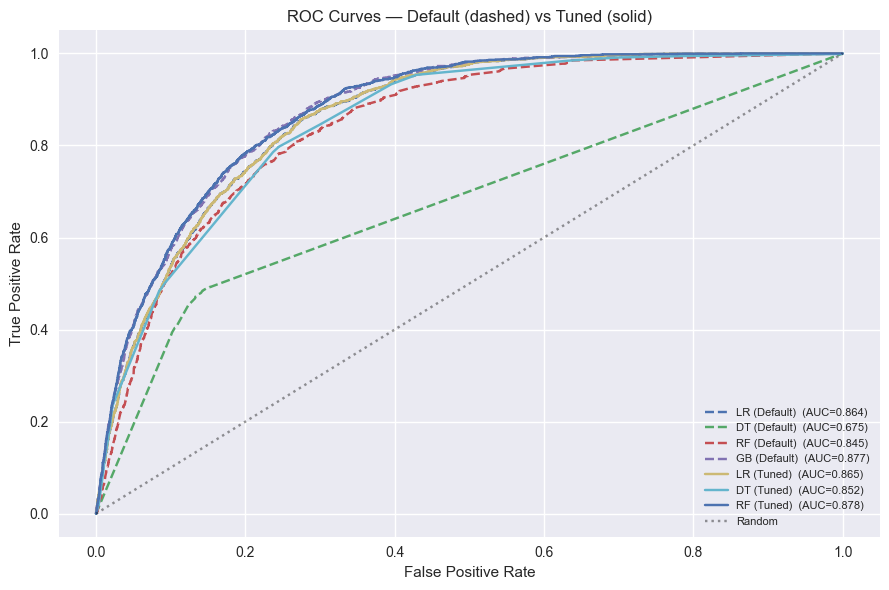

In [187]:
plt.figure(figsize=(9, 6))

for name, prob in [
    ('LR (Default)',  lr.predict_proba(X_test)[:, 1]),
    ('DT (Default)',  dt.predict_proba(X_test)[:, 1]),
    ('RF (Default)',  rf.predict_proba(X_test)[:, 1]),
    ('GB (Default)',  gb.predict_proba(X_test)[:, 1]),
    ('LR (Tuned)',    lr_prob_tuned),
    ('DT (Tuned)',    dt_prob_tuned),
    ('RF (Tuned)',    rf_prob_tuned)
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ls  = '-' if '(Tuned)' in name else '--'
    plt.plot(fpr, tpr, ls=ls, label=f'{name}  (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k:', alpha=0.4, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Default (dashed) vs Tuned (solid)')
plt.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

In [189]:
print(f'{"Model":<35} {"Mean AUC":>9} {"Std":>7}  Fold Scores')
print('-' * 75)

for name, model in [
    ('Logistic Regression (Tuned)', lr_grid.best_estimator_),
    ('Decision Tree (Tuned)',       dt_grid.best_estimator_),
    ('Random Forest (Tuned)',       rf_grid.best_estimator_)
]:
    scores = cross_val_score(model, X_train, y_train,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f'{name:<35} {scores.mean():>9.4f} {scores.std():>7.4f}  {np.round(scores, 4)}')

Model                                Mean AUC     Std  Fold Scores
---------------------------------------------------------------------------
Logistic Regression (Tuned)            0.8642  0.0040  [0.8702 0.8631 0.8623 0.867  0.8585]
Decision Tree (Tuned)                  0.8558  0.0047  [0.8628 0.8537 0.8532 0.8595 0.8497]
Random Forest (Tuned)                  0.8793  0.0029  [0.884  0.8795 0.8758 0.8802 0.8767]


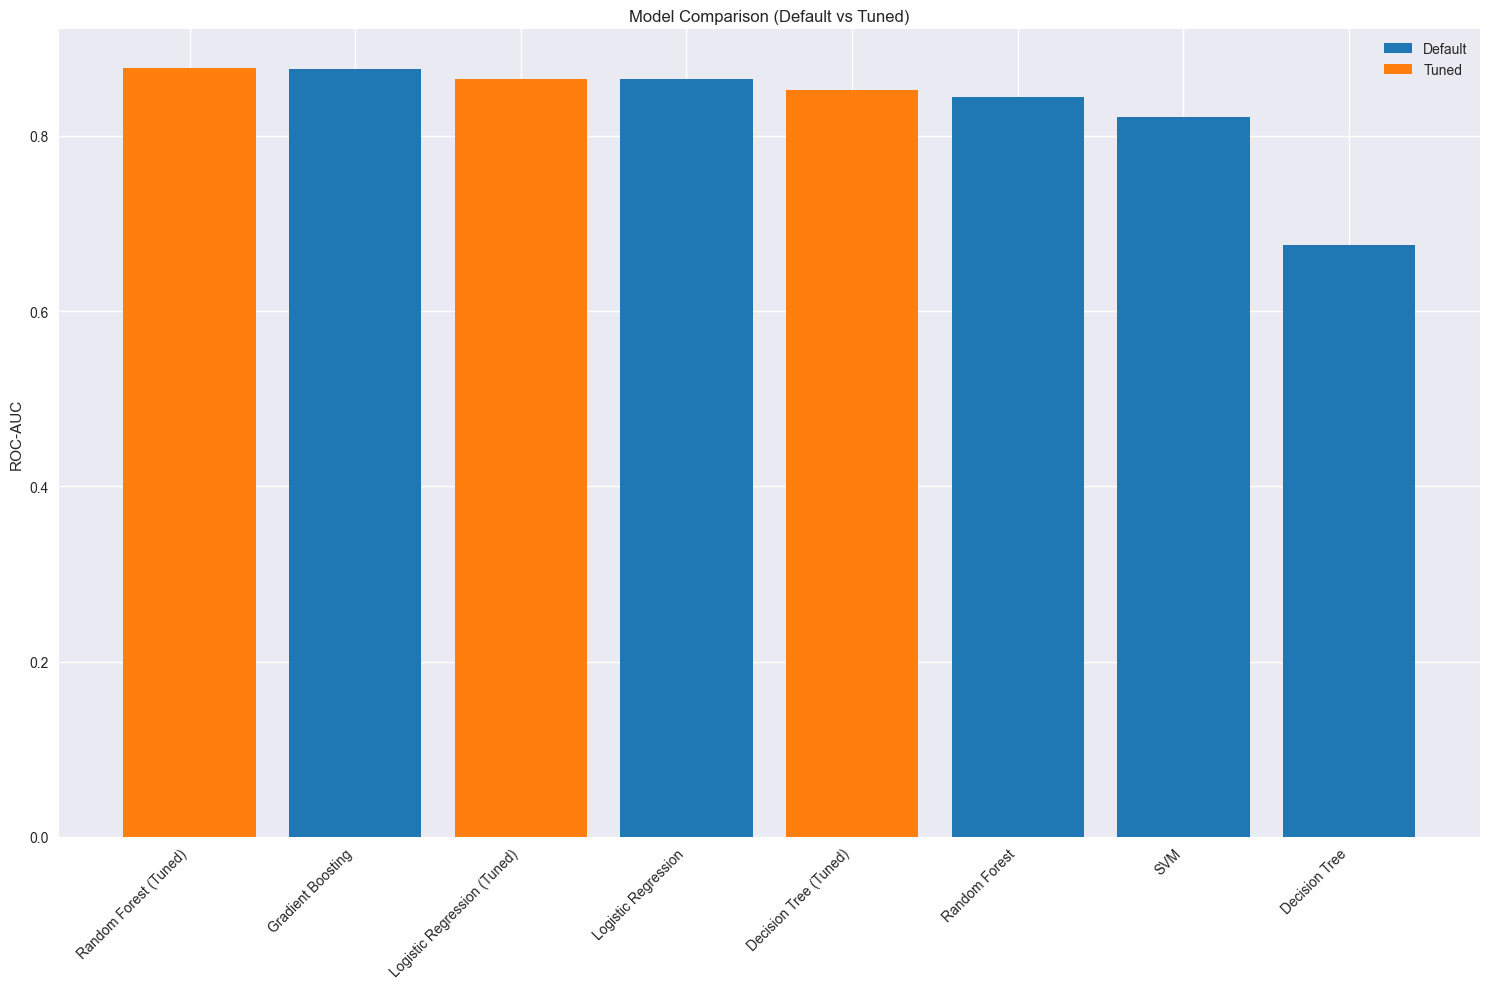

In [221]:
# Sort by ROC-AUC (optional but recommended)
final_df = final_df.sort_values(by="ROC-AUC", ascending=False)

plt.figure(figsize=(15,10))

# Color logic: default = blue, tuned = orange
colors = ["tab:orange" if "Tuned" in model else "tab:blue"
          for model in final_df["Model"]]

plt.bar(final_df["Model"], final_df["ROC-AUC"], color=colors)

plt.xticks(rotation=45, ha="right")
plt.ylabel("ROC-AUC")
plt.title("Model Comparison (Default vs Tuned)")

# Legend (manual so it's clear for grading)
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='tab:blue', label='Default'),
    Patch(facecolor='tab:orange', label='Tuned')
]
plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

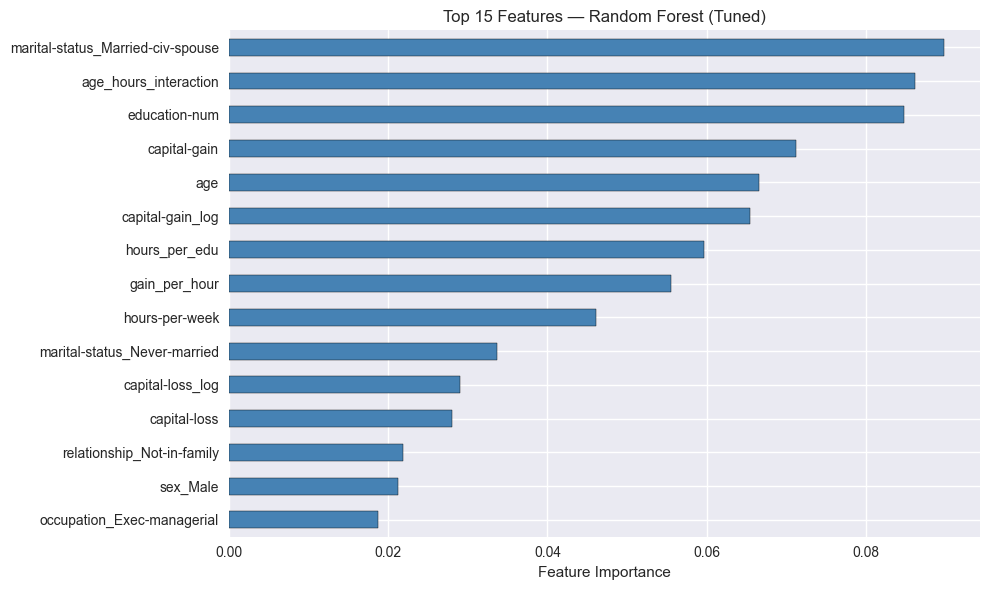

In [191]:
best_model      = rf_grid.best_estimator_
best_model_name = 'Random Forest (Tuned)'

importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
top15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top15.plot(kind='barh', color='steelblue', edgecolor='black')
plt.xlabel('Feature Importance')
plt.title(f'Top 15 Features — {best_model_name}')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Final Model Selection

The best-performing model is the *Random Forest (Tuned)* model.

It achieved:
- Test ROC-AUC: **0.878**
- CV Mean ROC-AUC: **0.877**
- Train ROC-AUC: **0.944**

This model performs better than all other models in terms of ROC-AUC and overall accuracy. Gradient Boosting is very close in performance, but Random Forest is slightly better overall.

Compared to the best default model (Random Forest without tuning, ROC-AUC = 0.845), the tuned version shows a clear improvement of about +0.033 ROC-AUC.

Although there is a small gap between training and test performance, the model still generalizes well and does not show severe overfitting. Overall, Random Forest (Tuned) is chosen as the final model because it performs the best while still generalizing well to new data.

## 6) Save Best Model

In [203]:
## save best model
import pickle, os
os.makedirs('../models', exist_ok=True)

with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print(f'Saved:  ../models/best_model.pkl')
print(f'Model:  {type(best_model).__name__}')
print(f'Params: {rf_grid.best_params_}')

Saved:  ../models/best_model.pkl
Model:  RandomForestClassifier
Params: {'max_depth': 20, 'max_features': 'log2', 'min_samples_split': 5, 'n_estimators': 200}


## Key Findings

1. The best overall model was Random Forest (Tuned) with a test ROC-AUC of 0.8776, outperforming all other models in the final comparison.

2. Hyperparameter tuning improved Random Forest’s ROC-AUC from 0.8446 to 0.8776, a gain of +0.0330, making it the most improved strong-performing model after tuning.

3. Decision Tree showed the largest tuning improvement, increasing from 0.6752 to 0.8522, a gain of +0.1769, but it still underperformed compared to ensemble methods.

4. SMOTE did not improve performance: Logistic Regression stayed at 0.8644 ROC-AUC, while Random Forest and Decision Tree decreased in performance, and recall dropped significantly (Decision Tree and Random Forest both declined). Because of this, the original dataset was used for all final modeling.

5. Cross-validation results were consistent with test performance, with all models showing CV standard deviations below 0.03, indicating stable performance across folds and no major variability concerns.